# Time Series Analysis Models for S&P 500

This notebook demonstrates two common time series analysis techniques for the S&P 500 index:

1. ARIMA (Autoregressive Integrated Moving Average) for forecasting future index returns
2. Exponential Smoothing for volatility estimation and forecasting

Both techniques are foundational in quantitative finance and algorithmic trading.

## Setup and Data Collection

First, let's import the necessary libraries and fetch S&P 500 historical data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import yfinance as yf

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

In [2]:
# Get S&P 500 historical data (last 3 years)
sp500 = yf.download('^GSPC', auto_adjust=False, start='2022-01-01')

# Display the first few rows
print(f"Data period: {sp500.index.min().date()} to {sp500.index.max().date()}")
print(f"Number of trading days: {len(sp500)}")
sp500.head()

[*********************100%***********************]  1 of 1 completed

Data period: 2022-01-03 to 2025-05-02
Number of trading days: 836


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
2022-01-03,4796.560059,4796.560059,4796.640137,4758.169922,4778.140137,3831020000
2022-01-04,4793.540039,4793.540039,4818.620117,4774.270020,4804.509766,4683170000
2022-01-05,4700.580078,4700.580078,4797.700195,4699.439941,4787.990234,4887960000
2022-01-06,4696.049805,4696.049805,4725.009766,4671.259766,4693.390137,4295280000
2022-01-07,4677.029785,4677.029785,4707.950195,4662.740234,4697.660156,4181510000


Let's visualize the S&P 500 price history:

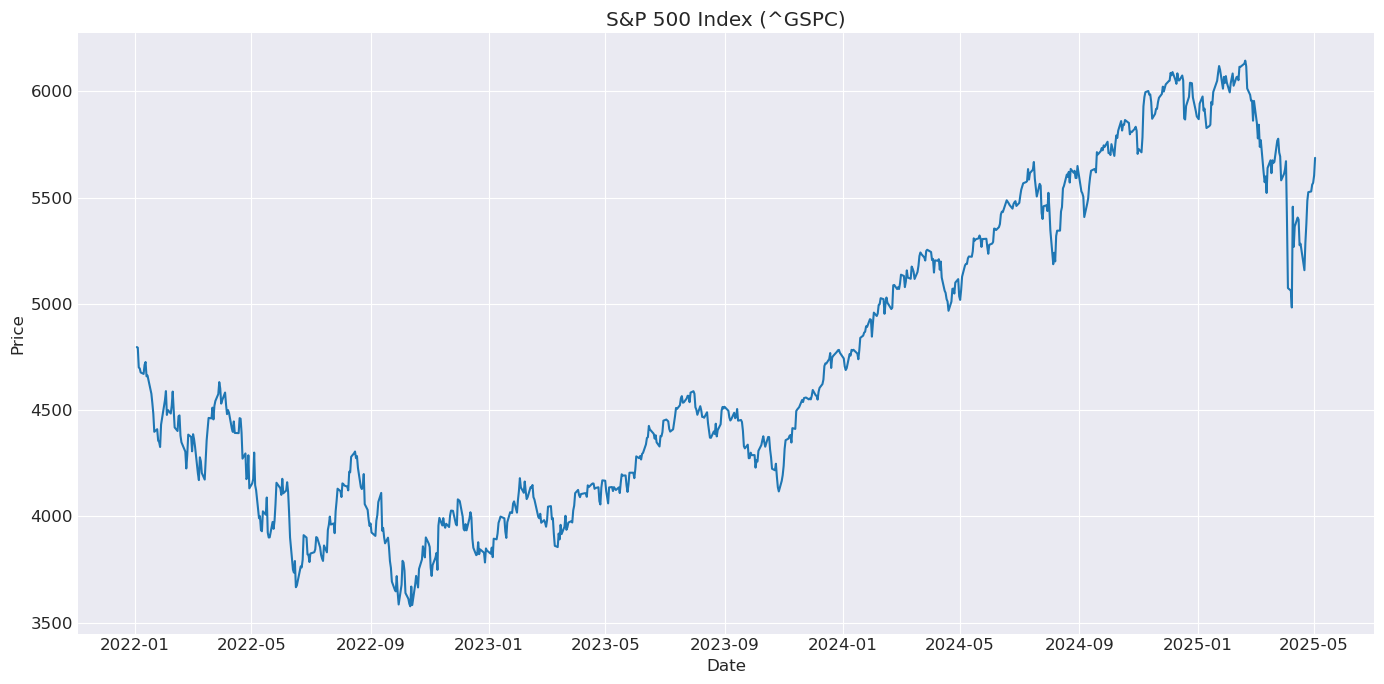

In [3]:
plt.figure(figsize=(14, 7))
plt.plot(sp500['Close'])
plt.title('S&P 500 Index (^GSPC)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

## 1. ARIMA Model for S&P 500 Index Forecasting

ARIMA (Autoregressive Integrated Moving Average) models are widely used for time series forecasting. Here, we'll build an ARIMA model to forecast future returns of the S&P 500 index.

First, let's calculate daily returns and visualize them:

Price         Adj Close        Close         High          Low         Open  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC   
Date                                                                          
2022-01-03  4796.560059  4796.560059  4796.640137  4758.169922  4778.140137   
2022-01-04  4793.540039  4793.540039  4818.620117  4774.270020  4804.509766   
2022-01-05  4700.580078  4700.580078  4797.700195  4699.439941  4787.990234   
2022-01-06  4696.049805  4696.049805  4725.009766  4671.259766  4693.390137   
2022-01-07  4677.029785  4677.029785  4707.950195  4662.740234  4697.660156   

Price           Volume   Returns  
Ticker           ^GSPC            
Date                              
2022-01-03  3831020000       NaN  
2022-01-04  4683170000 -0.000630  
2022-01-05  4887960000 -0.019393  
2022-01-06  4295280000 -0.000964  
2022-01-07  4181510000 -0.004050  


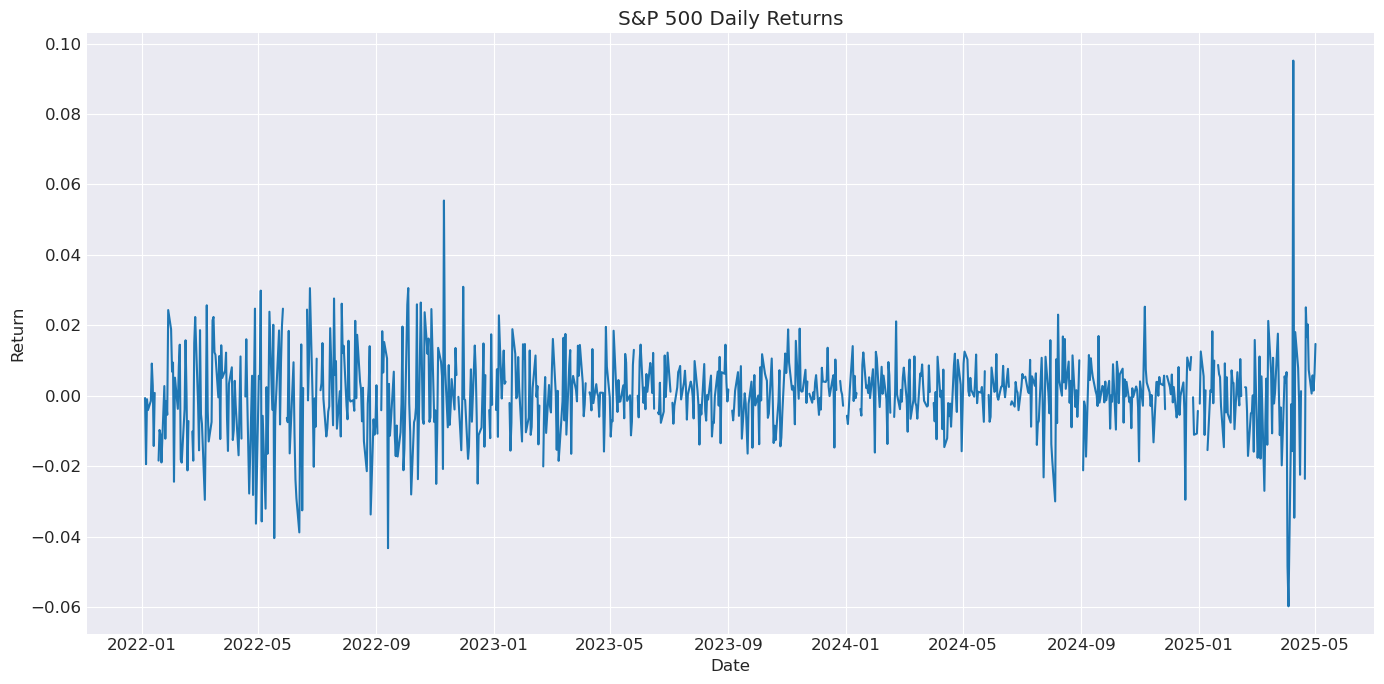

In [4]:
# Calculate daily returns
sp500['Returns'] = sp500['Close']['^GSPC'].ffill().pct_change()
returns = sp500['Returns'].dropna().asfreq('B')
print(sp500.head())
# Plot returns
plt.figure(figsize=(14, 7))
plt.plot(returns)
plt.title('S&P 500 Daily Returns')
plt.xlabel('Date')
plt.ylabel('Return')
plt.grid(True)
plt.tight_layout()
plt.show()

Let's analyze the statistical properties of these returns:

In [5]:
# Calculate summary statistics for returns
print("Statistical properties of daily returns:")
print(f"Mean: {returns.mean():.6f}")
print(f"Standard Deviation: {returns.std():.6f}")
print(f"Minimum: {returns.min():.6f}")
print(f"Maximum: {returns.max():.6f}")
print(f"Skewness: {returns.skew():.6f}")
print(f"Kurtosis: {returns.kurtosis():.6f}")

Statistical properties of daily returns:
Mean: 0.000274
Standard Deviation: 0.011854
Minimum: -0.059750
Maximum: 0.095154
Skewness: 0.223591
Kurtosis: 6.617304


Now, let's fit an ARIMA model to the return series. 

We'll use an ARIMA(2,1,1) model, which means:
- 2 autoregressive terms (AR)
- 1st order differencing (I)
- 1 moving average terms (MA)

In [6]:
# Fit ARIMA model
model = ARIMA(returns, order=(5, 0, 0))
model_fit = model.fit()

# Display model summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Returns   No. Observations:                  869
Model:                 ARIMA(5, 0, 0)   Log Likelihood                2521.619
Date:                Sat, 03 May 2025   AIC                          -5029.237
Time:                        12:07:00   BIC                          -4995.866
Sample:                    01-04-2022   HQIC                         -5016.468
                         - 05-02-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      0.630      0.529      -0.001       0.001
ar.L1         -0.0122      0.024     -0.510      0.610      -0.059       0.035
ar.L2          0.0060      0.032      0.189      0.8

Let's plot the model's diagnostics to assess its fit:

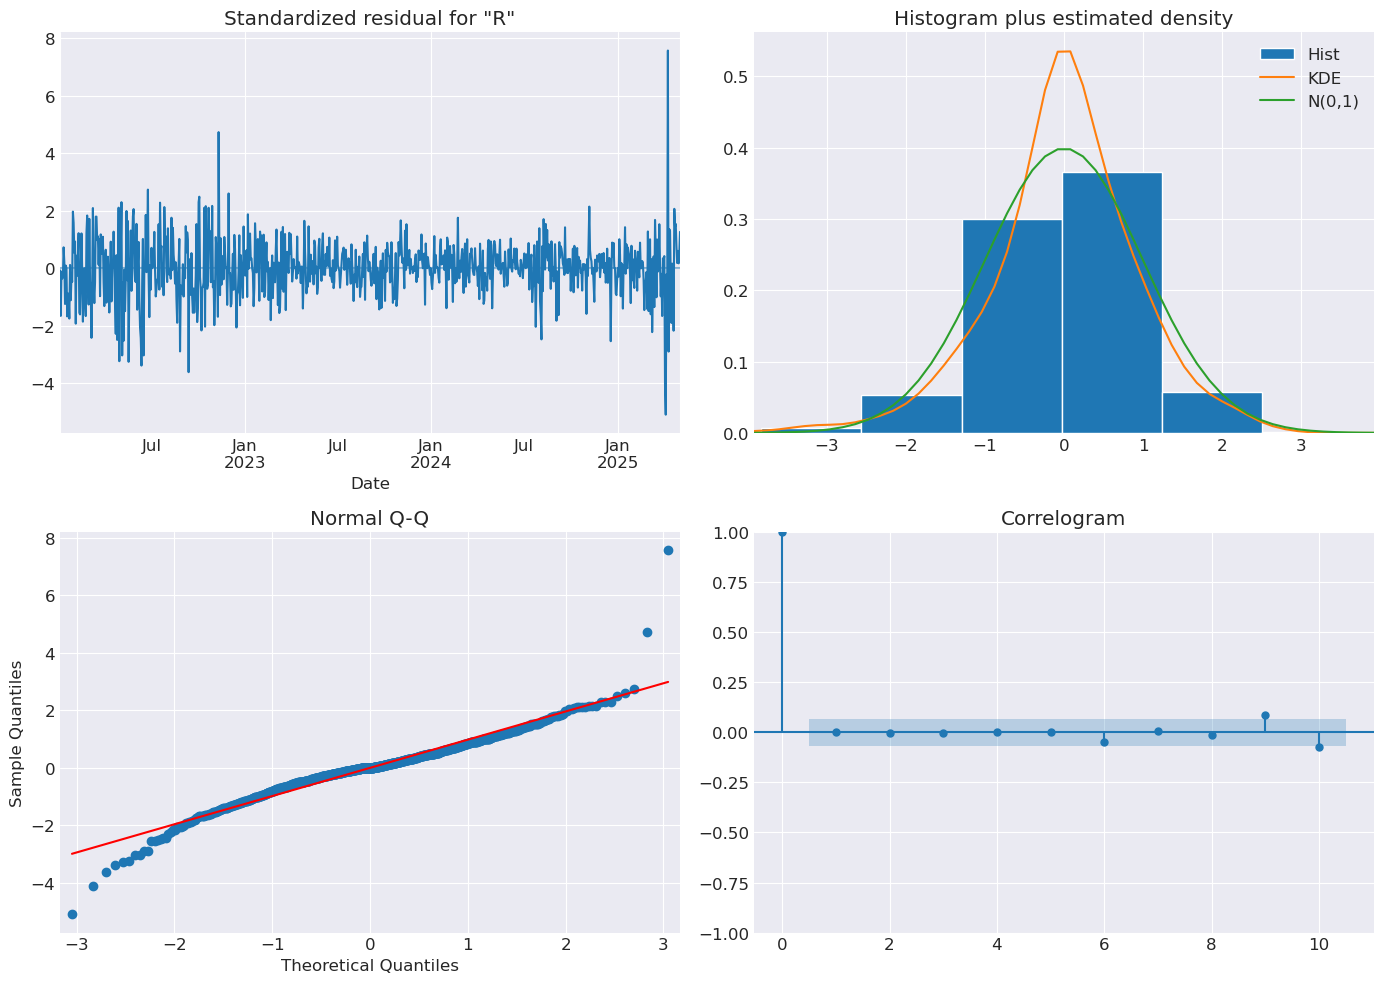

In [7]:
# Plot model diagnostics
model_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

Now, let's forecast the next 10 trading days:

In [8]:
# Forecast next 10 days
forecast = model_fit.forecast(steps=10)
forecast_df = pd.DataFrame({
    'Forecasted Return': forecast,
    'Lower CI': forecast - 1.96 * model_fit.params['sigma2'] ** 0.5,
    'Upper CI': forecast + 1.96 * model_fit.params['sigma2'] ** 0.5
})

print("Forecasted S&P 500 returns for next 10 trading days:")
forecast_df

Forecasted S&P 500 returns for next 10 trading days:


,Forecasted Return,Lower CI,Upper CI
2025-05-05,-0.000049,-0.023183,0.023085
2025-05-06,-0.000099,-0.023233,0.023035
2025-05-07,-0.000937,-0.024071,0.022197
2025-05-08,0.000145,-0.022988,0.023279
2025-05-09,0.000386,-0.022748,0.023520
2025-05-12,0.000349,-0.022784,0.023483
2025-05-13,0.000278,-0.022856,0.023412
2025-05-14,0.000240,-0.022894,0.023373
2025-05-15,0.000247,-0.022887,0.023381
2025-05-16,0.000254,-0.022879,0.023388


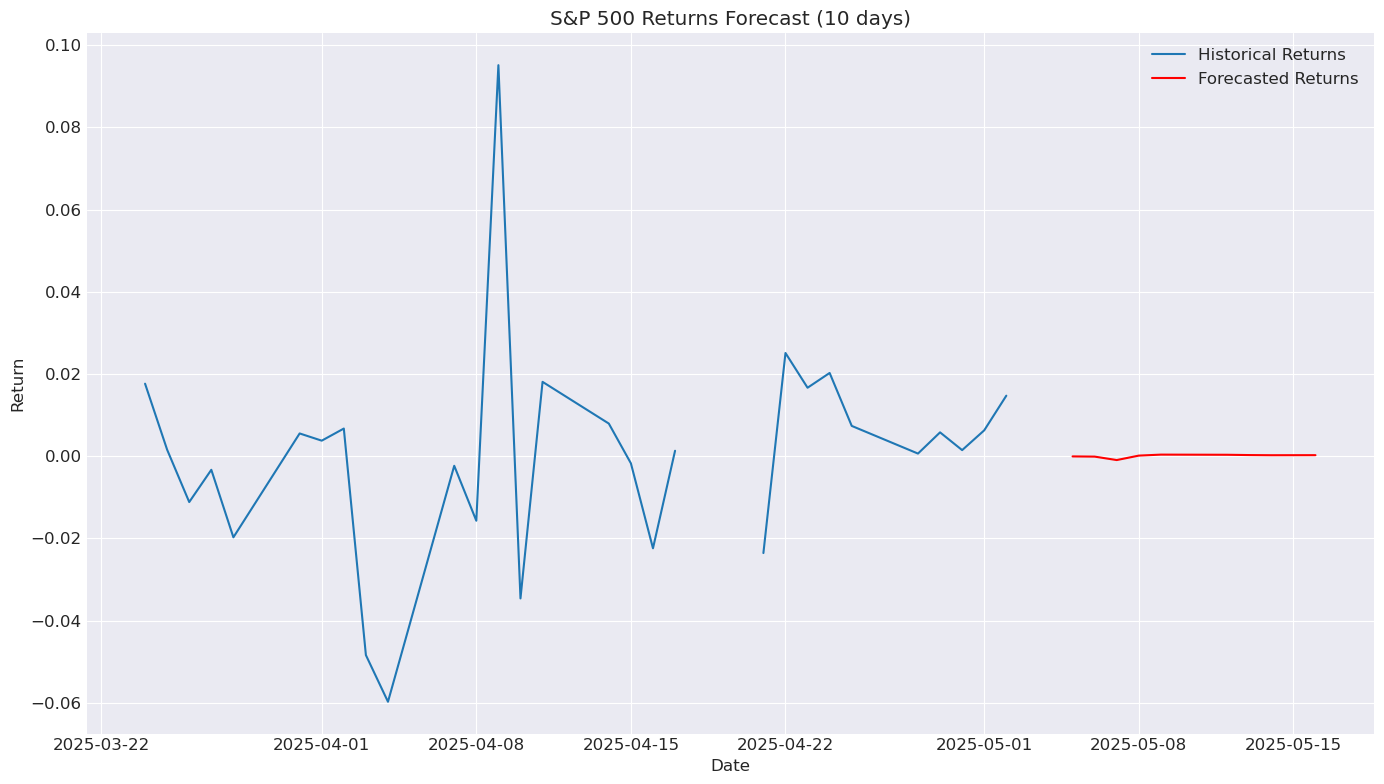

In [9]:
# Plot historical returns
plt.plot(returns[-30:], label='Historical Returns')

# The forecast object already has the correct index
last_date = returns.index[-1]
forecast_idx = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10)
forecast_series = pd.Series(forecast, index=forecast_idx)

# Plot forecast using the forecast Series directly
plt.plot(forecast, color='red', label='Forecasted Returns')
plt.title('S&P 500 Returns Forecast (10 days)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Exponential Smoothing for Volatility Estimation

Exponential smoothing is another popular technique for time series analysis. Here, we'll use it to model and forecast the volatility of the S&P 500.

First, let's calculate the rolling volatility:

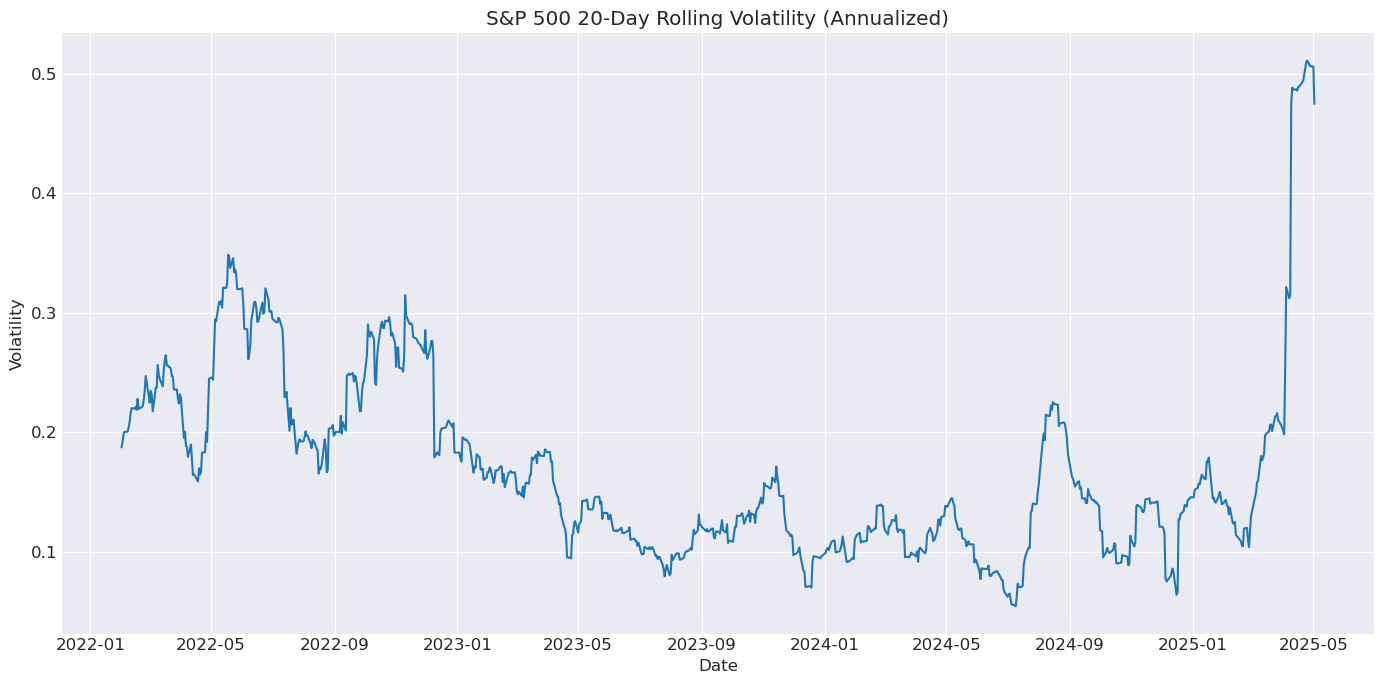

In [10]:
# Calculate rolling volatility (20-day window)
sp500['Volatility'] = sp500['Returns'].rolling(window=20).std() * np.sqrt(252)

# Plot volatility
plt.figure(figsize=(14, 7))
plt.plot(sp500['Volatility'].dropna())
plt.title('S&P 500 20-Day Rolling Volatility (Annualized)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid(True)
plt.tight_layout()
plt.show()

Now, let's apply exponential smoothing to the volatility series:

/opt/conda/envs/finmath/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


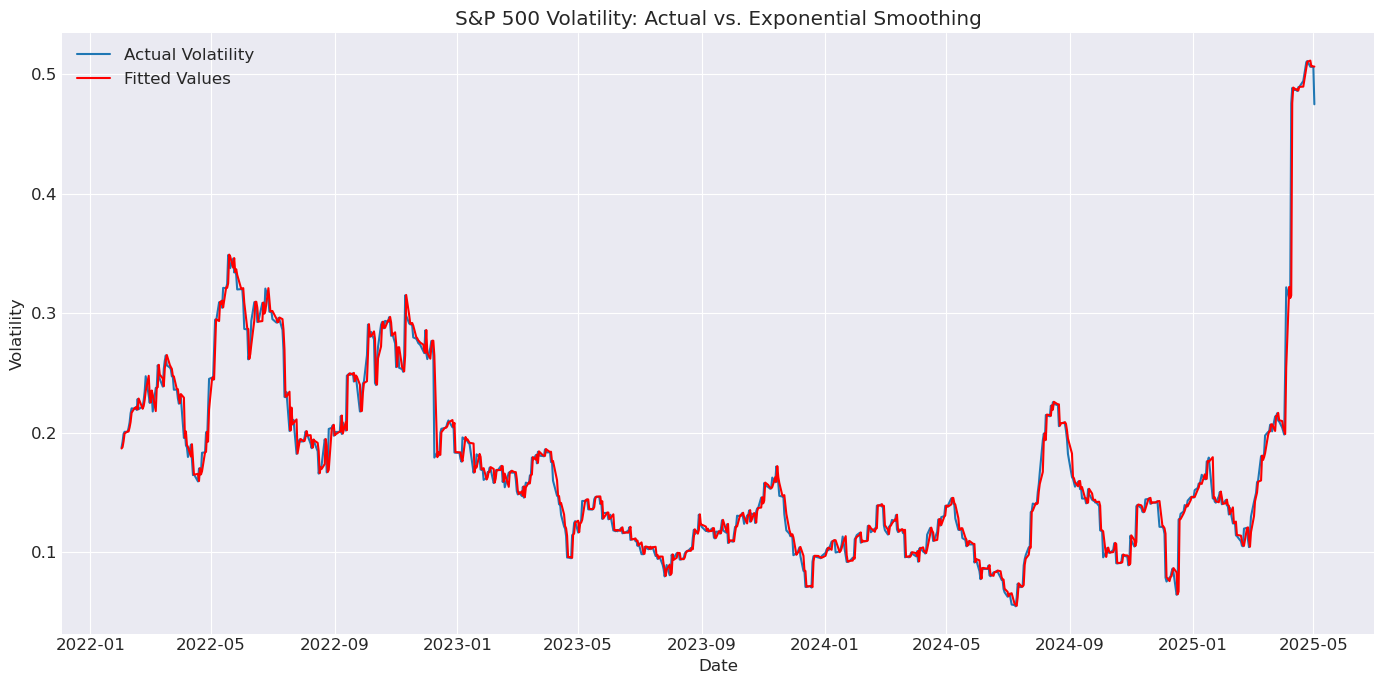

In [11]:
# Apply exponential smoothing to volatility
volatility_series = sp500['Volatility'].dropna()
model = ExponentialSmoothing(volatility_series, trend='add', seasonal=None)
fit = model.fit()

# Plot actual vs. fitted values
plt.figure(figsize=(14, 7))
plt.plot(volatility_series, label='Actual Volatility')
plt.plot(fit.fittedvalues, color='red', label='Fitted Values')
plt.title('S&P 500 Volatility: Actual vs. Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now, let's forecast future volatility:

/opt/conda/envs/finmath/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/conda/envs/finmath/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


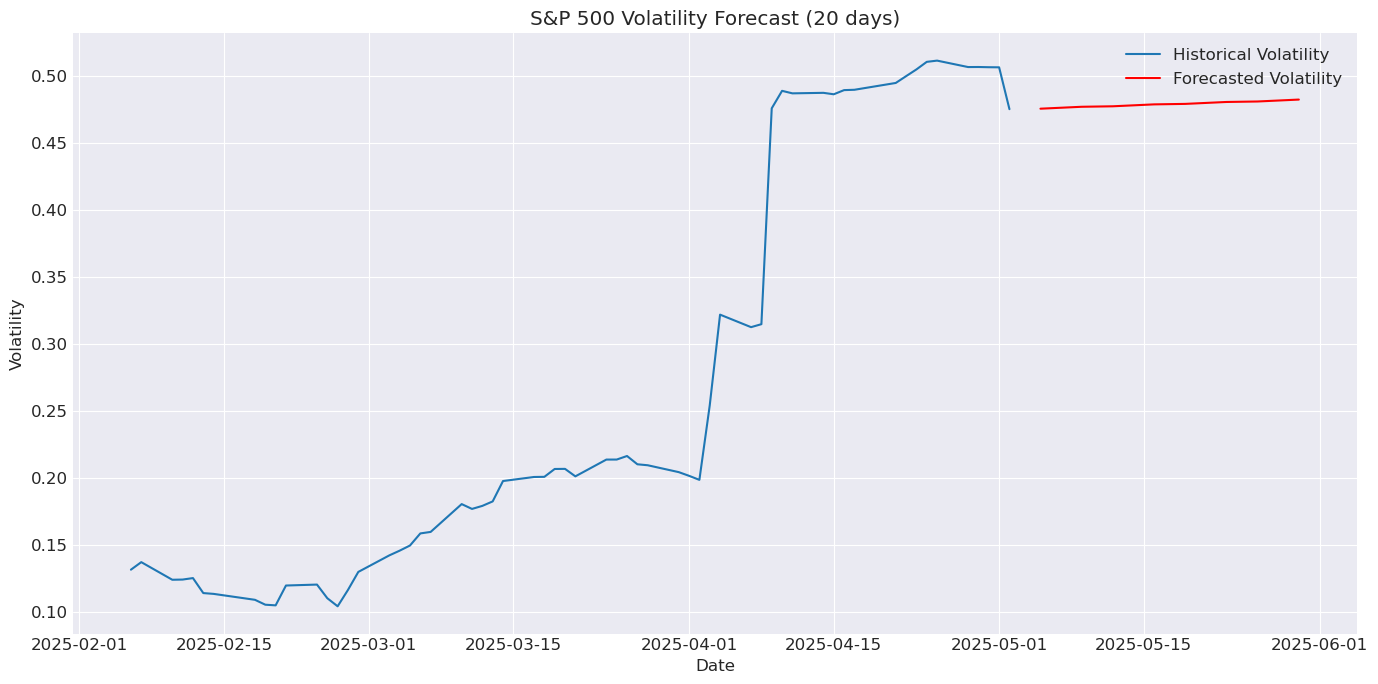

In [12]:
# Forecast volatility for next 20 trading days
volatility_forecast = fit.forecast(20)

# Create a date range for the forecast period
last_date = volatility_series.index[-1]
forecast_idx = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=20, freq='B')
volatility_forecast.index = forecast_idx

# Plot forecast
plt.figure(figsize=(14, 7))
plt.plot(volatility_series[-60:], label='Historical Volatility')
plt.plot(volatility_forecast, color='red', label='Forecasted Volatility')
plt.title('S&P 500 Volatility Forecast (20 days)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
# Display forecasted volatility
print("Volatility forecast for next 20 trading days (annualized):")
pd.DataFrame({
    'Date': volatility_forecast.index.date,
    'Forecasted Volatility': volatility_forecast.values
})

Volatility forecast for next 20 trading days (annualized):


,Date,Forecasted Volatility
0,2025-05-05,0.475311
1,2025-05-06,0.475669
2,2025-05-07,0.476027
3,2025-05-08,0.476385
4,2025-05-09,0.476743
5,2025-05-12,0.477101
6,2025-05-13,0.477459
7,2025-05-14,0.477817
8,2025-05-15,0.478176
9,2025-05-16,0.478534


## Algorithmic Trading Applications

Here are some ways these time series models can be applied in algorithmic trading:

1. **ARIMA Return Forecasts**:
   - Generate buy/sell signals based on the predicted direction of returns
   - Use forecasted returns to optimize portfolio allocation
   - Combine with other signals for enhanced trading strategies

2. **Volatility Forecasts**:
   - Size positions inversely proportional to expected volatility
   - Trade volatility directly through VIX derivatives
   - Set dynamic stop-loss levels based on predicted volatility
   - Adjust options strategies based on forecasted volatility
   
Both models provide valuable information for risk management and trade timing in algorithmic strategies.